In [51]:
# 🌟 Tutorial: Simple Chatbot with persistence using LangGraph and LangChain 🌟

In [52]:
# 1️⃣ Import required libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver

In [53]:
# 2️⃣ Define the state structure
# ChatState will hold all messages exchanged between user and chatbot
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [54]:
# 3️⃣ Initialize the language model (LLM)
llm = ChatOpenAI(model="gpt-4o-mini")

In [55]:

# 4️⃣ Define the main chatbot node function
def chat_node(state: ChatState):
    """
    This function gets user messages from the state,
    sends them to the language model, and stores the response.
    """
    # Get user messages from state
    messages = state['messages']
    
    # Send messages to the language model
    response = llm.invoke(messages)
    
    # Store the response back into the state
    return {'messages': [response]}


In [56]:
# 5️⃣ Create the StateGraph with our ChatState
graph = StateGraph(ChatState)

# 6️⃣ Add the chatbot node to the graph
graph.add_node('chat_node', chat_node)

# 7️⃣ Connect the nodes: START -> chat_node -> END
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

In [57]:
# 8️⃣ Compile the graph into a callable chatbot

checkpointer = MemorySaver()

chatbot = graph.compile(checkpointer = checkpointer)


In [58]:
# # 8️⃣ Compile the graph into a callable chatbot
# chatbot = graph.compile()

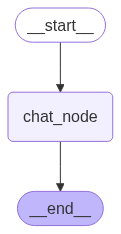

In [59]:
# Draw the Graph
from IPython.display import Image

Image(chatbot.get_graph().draw_mermaid_png())

In [60]:
# # 5️⃣ Interactive loop: keep chatting until user types exit
# while True:
#     # Take user input
#     user_message = input('Type here: ')
    
#     # Print user input
#     print('User:', user_message)
    
#     # Exit condition
#     if user_message.strip().lower() in ['leave', 'stop', 'goodbye']:
#         print('Chat ended.')
#         break





#     # Invoke chatbot
#     response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
#       # Print AI response
#     print('AI:', response['messages'][-1].content)

In [61]:
thread_id = '1'
config = {"configurable": {"thread_id": thread_id}}



# 5️⃣ Interactive loop: keep chatting until user types exit
while True:
    # Take user input
    user_message = input('Type here: ')
    
    # Print user input
    print('User:', user_message)
    
    # Exit condition
    if user_message.strip().lower() in ['leave', 'stop', 'goodbye']:
        print('Chat ended.')
        break




    
    # Invoke chatbot
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config = config)

    # Print AI response
    print('AI:', response['messages'][-1].content)

User: my name is pawan
AI: Nice to meet you, Pawan! How can I assist you today?
User: hi
AI: Hi, Pawan! How's your day going?
User: what is my name?
AI: Your name is Pawan. How can I help you today?
User: hello
AI: Hello again, Pawan! What would you like to talk about today?
User: add 2 and 3
AI: 2 plus 3 equals 5. If you have any more math questions or anything else you'd like to know, feel free to ask!
User: add 5  more
AI: If you add 5 to 5, the result is 10. If you meant something else, please clarify!
User: leave
Chat ended.


In [63]:
chatbot.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='my name is pawan', additional_kwargs={}, response_metadata={}, id='82015589-6856-4f4c-b067-3d9017b684e8'), AIMessage(content='Nice to meet you, Pawan! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 12, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-C9PLt2x0cI6Hy50t07AU6sfepw6zT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--ad14b48e-8489-460b-9e84-cfc09cef9665-0', usage_metadata={'input_tokens': 12, 'output_tokens': 15, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'r